<h1 style="color:#ffffff; background-color:#3E4C59; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Day 4 — Feature Engineering &amp; Hyperparameter Tuning</h1>
<h3 style="color:#52677A; text-align:center; font-weight:bold; margin-top:0;">Better Features, Then a Systematic Search Instead of Guessing</h3>


<a id="toc"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. Why Feature Engineering Often Beats Model Choice</a></li>
<li><a href="#section2">2. Common Feature Engineering Techniques</a></li>
<li><a href="#section3">3. Hyperparameters vs. Parameters</a></li>
<li><a href="#section4">4. GridSearchCV</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference</a></li>
<li><a href="#section7">7. Hands-On Lab — Engineering Features &amp; Tuning</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Day 3 taught us to diagnose fit and regularize by hand. Today we automate two things: turning raw columns into better features, and searching hyperparameters systematically instead of guessing them one at a time.
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Why Feature Engineering Often Beats Model Choice</h2>
<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 What is a "feature"?</h3>
A <b>feature</b> is simply one input column the model is allowed to look at — <code>Age</code>, <code>Fare</code>, <code>Pclass</code>. The model never sees the raw world; it only ever sees the columns you hand it. If an important pattern is not represented in any column, no algorithm, however powerful, can learn it.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 What is "feature engineering"?</h3>
<b>Feature engineering</b> is the process of creating, transforming, and selecting the input variables the model learns from. It is where <i>domain understanding</i> — what you personally know about the problem — gets turned into something a model can actually use as a number.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">1.3 Why it usually beats a fancier model</h3>
A common professional truth: better features usually improve results more than a fancier model. Swapping a Random Forest for a bigger, slower model rarely fixes a model that is missing an obviously useful signal — but adding that one missing feature often does.

<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> In practice, most of the measurable gain in a real-world ML project comes from data and feature quality, not from chasing a marginally fancier algorithm. This is why feature engineering is one of the highest-leverage skills an AI/ML practitioner can have: it directly controls how much signal the model is even given the chance to learn from, before any algorithm choice matters at all.
</div>


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Before reaching for a bigger model or a wider hyperparameter grid, ask first: is there a feature the model is missing that a human would obviously use?
</div>


<a id="section2"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Common Feature Engineering Techniques</h2>
Below are the five techniques used throughout this course. Each one takes a raw column (or set of columns) and reshapes it into something more informative for the model.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Technique</th><th style="padding:8px; text-align:left;">What It Does</th><th style="padding:8px; text-align:left;">Example</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Creating features</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Combine existing columns into a more informative one</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">price_per_sqm = price / area</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Binning</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Group a continuous variable into ranges</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">age → child / adult / senior</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">One-hot encoding</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Convert categories into numeric columns</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">city → city_Nablus, city_Ramallah, ...</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Datetime extraction</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Pull signal from dates</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">order_date → day_of_week, month</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Scaling</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Put numeric features on a comparable range</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">StandardScaler, MinMaxScaler</td></tr>
</table>
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Creating features — why combine columns at all?</h3>
A model can only combine columns in the ways its algorithm allows (a linear model, for example, can only combine features by weighted addition). If the <i>true</i> useful signal is a ratio or a sum of existing columns, handing the model that combination directly — instead of hoping it discovers the ratio on its own — makes learning dramatically easier.

In [2]:
# A quick illustration of "creating features": combining two existing columns into a more informative one
demo = pd.DataFrame({"sibsp": [1, 0, 3], "Parch": [0, 0, 2]})

# family_size is a classic Titanic engineered feature: siblings/spouses + parents/children + self
demo["family_size"] = demo["sibsp"] + demo["Parch"] + 1
demo

,sibsp,Parch,family_size
0,1,0,2
1,0,0,1
2,3,2,6


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> A single engineered feature like <code>family_size</code> can carry more predictive signal than <code>sibsp</code> and <code>Parch</code> separately, because it directly captures "was this passenger traveling alone or with a group?"
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 Binning — why turn a number into a category?</h3>
Some relationships are not smooth or linear — for example, both very young children and elderly passengers might behave differently from adults, but not in a way that increases steadily with age. <b>Binning</b> groups a continuous variable into ranges (e.g. child / adult / senior), letting the model learn a separate effect for each group instead of forcing one smooth trend across the whole range.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.3 One-hot encoding — why can't a model just read text categories?</h3>
Most ML algorithms only understand numbers, and they assume numeric order means something (e.g. that 3 is "more" than 1). A category like <code>city</code> has no natural order, so assigning it raw numbers (Nablus=1, Ramallah=2 ...) would invent a false ranking. <b>One-hot encoding</b> instead creates one 0/1 column per category, so the model can weigh each category independently without any implied order.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.4 Datetime extraction — why not just feed in the date directly?</h3>
A raw date is nearly meaningless to most models as a single number. What usually matters is the <i>pattern</i> hidden inside the date — the day of the week, the month, whether it's a weekend. <b>Datetime extraction</b> pulls those patterns out into their own columns so the model can actually use them.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">2.5 Scaling — why does the numeric range matter?</h3>
Many algorithms (anything based on distance or gradient steps) are sensitive to the <i>scale</i> of a feature. If <code>Age</code> ranges 0–80 and <code>Fare</code> ranges 0–500, a distance-based model can end up treating Fare as far more important purely because its numbers are bigger — not because it actually carries more signal. <b>Scaling</b> (e.g. <code>StandardScaler</code>, <code>MinMaxScaler</code>) puts every numeric feature on a comparable range so the model judges importance based on the pattern in the data, not the units it happened to be recorded in.

<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> Every one of these techniques exists to remove a mismatch between how information is naturally represented (dates, categories, raw counts, mixed scales) and what a learning algorithm can actually process. Getting this translation right is often the difference between a model that looks like it "isn't smart enough" and one that performs well — even though the underlying algorithm never changed.
</div>


<a id="section3"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Hyperparameters vs. Parameters</h2>
<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 What is a parameter?</h3>
A <b>parameter</b> is a value the model <i>learns for itself</i> during training — for example, a linear regression's coefficients, or the split thresholds inside a decision tree. You never set these by hand; <code>.fit()</code> discovers them from the data.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 What is a hyperparameter?</h3>
A <b>hyperparameter</b> is a value <i>you</i> choose before training even starts — a tree's <code>max_depth</code>, k in k-NN, <code>alpha</code> in Ridge, the number of trees in a forest. It controls <i>how</i> the model is allowed to learn, not what it learns.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">3.3 Why the distinction matters</h3>
Finding good hyperparameters is a search problem, and doing it by hand — trying one value, checking the score, trying another — is slow and unsystematic. It also silently reuses the validation set over and over, which is exactly the "tuning against one split" risk introduced back on Day 1.

<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> Day 3's <code>max_depth</code> and <code>alpha</code> choices were picked by hand, one value at a time. That does not scale past two or three values — GridSearchCV is the systematic replacement.
</div>


<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> Hyperparameters are the "knobs" that shape how every model in this course learns — bias-variance trade-off (Day 3), regularization strength (Day 3), and tree depth (Day 3-4) are all hyperparameters. Understanding parameters vs. hyperparameters is what lets you reason about <i>why</i> a model behaves the way it does, instead of treating it as an unexplainable black box.
</div>


<a id="section4"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. GridSearchCV</h2>
<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 What GridSearchCV automates</h3>
GridSearchCV automates hyperparameter tuning: you define a grid of values to try, and it trains and cross-validates a model for every combination, then reports the best one. It combines the search with cross-validation, so the chosen hyperparameters are selected on a reliable estimate rather than a single lucky split.

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 Why cross-validation is built into the search</h3>
If GridSearchCV picked hyperparameters using a single validation score, it would be exposed to exactly the same "lucky/unlucky split" risk from Day 2. By cross-validating every combination internally, the search compares combinations on a stable, averaged score instead of noise.

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Illustrative only -- we run this for real on the Titanic dataset in Section 7
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
}
# grid = GridSearchCV(RandomForestClassifier(random_state=42),
#                      param_grid, cv=5, scoring="f1")
# grid.fit(X_train, y_train)
# print(grid.best_params_)   # the winning combination
# print(grid.best_score_)    # its cross-validated score
# best_model = grid.best_estimator_

print("We will run GridSearchCV for real on the Titanic dataset in Section 7.")

We will run GridSearchCV for real on the Titanic dataset in Section 7.


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Grid search cost grows fast: 2 values × 3 values × 5 folds = 30 model fits. For large grids, <code>RandomizedSearchCV</code> samples a subset of combinations and is far faster.
</div>


<div style="border-left:5px solid #52677A; background-color:#eef2f4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#2C3640;">
<b>Why it matters in AI:</b> GridSearchCV is the bridge between everything learned this week: it needs a correct train/test split (Day 1) so it never touches held-out data, it relies on cross-validation (Day 2) internally for every candidate, and the hyperparameters it searches over are exactly the knobs used to fight overfitting and underfitting (Day 3). It turns model tuning from guesswork into a reproducible, evidence-based procedure — a core expectation of any serious AI/ML workflow.
</div>


<a id="section5"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li><b>Engineering features from the whole dataset before splitting</b> — statistics used to build a feature (e.g. a mean) must come from training data only, or information leaks into validation/test.</li>
<li><b>Confusing hyperparameters with parameters</b> — hyperparameters are set before training and searched; parameters are learned during <code>.fit()</code> and are never searched by hand.</li>
<li><b>Grid searching against the test set</b> — GridSearchCV's <code>cv</code> uses the training set only; the held-out test set stays untouched until the final check, exactly as in Day 1.</li>
<li><b>Grids that are too large</b> — every extra value multiplies the number of model fits; prefer <code>RandomizedSearchCV</code> once a grid gets large.</li>
<li><b>Skipping the untuned baseline comparison</b> — without comparing against Week 3's baseline, there is no evidence the tuning actually helped.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#52677A; color:#D9C08C;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import GridSearchCV</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from sklearn.model_selection import GridSearchCV</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Define a hyperparameter grid</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>param_grid = {"n_estimators": [100, 200], "max_depth": [5, 10, None]}</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Run the grid search</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>grid = GridSearchCV(model, param_grid, cv=5, scoring="f1")</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fit the search</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>grid.fit(X_train, y_train)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Winning combination</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>grid.best_params_</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Its cross-validated score</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>grid.best_score_</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">The refit best model</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>grid.best_estimator_</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Faster search for large grids</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>RandomizedSearchCV</code></td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Engineering Features &amp; Tuning</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Engineer at least two new features and justify each, define a hyperparameter grid for a Week 3 model, run GridSearchCV with 5-fold cross-validation, compare the tuned score against the untuned baseline, and document which feature and which hyperparameter mattered most.
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">7.0 Loading the dataset</h3>
We reuse <code>train_and_test2.csv</code>, the same Titanic passenger dataset from Days 1–3, predicting whether a passenger survived.

In [4]:
titanic = pd.read_csv("train_and_test2.csv")
titanic = titanic.rename(columns={"2urvived": "Survived"})

titanic.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,Survived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Create at least two new engineered features for the dataset and justify each</h3>


In [5]:
titanic_fe = titanic.copy()

# Engineered feature 1: family_size -- captures whether a passenger traveled alone or with a group,
# a well-known signal for Titanic survival (small groups survived more than solo travelers or huge families)
titanic_fe["family_size"] = titanic_fe["sibsp"] + titanic_fe["Parch"] + 1

# Engineered feature 2: fare_per_person -- a single fare can represent a whole family's ticket,
# so dividing by family size gives a more comparable per-passenger fare
titanic_fe["fare_per_person"] = titanic_fe["Fare"] / titanic_fe["family_size"]

# Engineered feature 3: is_alone -- a simple binary flag, since solo travelers behaved differently
# from passengers traveling with family
titanic_fe["is_alone"] = (titanic_fe["family_size"] == 1).astype(int)

titanic_fe[["sibsp", "Parch", "family_size", "Fare", "fare_per_person", "is_alone"]].head()

,sibsp,Parch,family_size,Fare,fare_per_person,is_alone
0,1,0,2,7.2500,3.62500,0
1,1,0,2,71.2833,35.64165,0
2,0,0,1,7.9250,7.92500,1
3,1,0,2,53.1000,26.55000,0
4,0,0,1,8.0500,8.05000,1


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> <b>Justification:</b> <code>family_size</code> and <code>is_alone</code> capture group-travel effects that <code>sibsp</code>/<code>Parch</code> alone leave split across two columns. <code>fare_per_person</code> normalizes a family's shared ticket fare into a per-passenger value, which is more comparable across passengers than the raw <code>Fare</code>.
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Define a hyperparameter grid for a model from Week 3 (random forest)</h3>


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

engineered_features = ["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass",
                        "family_size", "fare_per_person", "is_alone"]
X = titanic_fe[engineered_features]
y = titanic_fe["Survived"]

# Same three-way split discipline as Days 1-3
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
}
param_grid

{'n_estimators': [100, 200], 'max_depth': [5, 10, None]}

<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Run GridSearchCV with 5-fold cross-validation and report the best parameters and score</h3>


In [7]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                     param_grid, cv=5, scoring="f1")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best cross-validated F1: {grid.best_score_:.3f}")

Best params: {'max_depth': 10, 'n_estimators': 200}
Best cross-validated F1: 0.517


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Compare the tuned model's cross-validated score against the untuned baseline from Week 3</h3>


In [8]:
from sklearn.model_selection import cross_val_score

# Untuned baseline: default RandomForestClassifier on the ORIGINAL (non-engineered) features,
# matching the Week 3 / Day 1 baseline model
baseline_features = ["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass"]
X_baseline = titanic[baseline_features]
X_base_temp, X_base_test, y_base_temp, y_base_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42)
X_base_train, X_base_val, y_base_train, y_base_val = train_test_split(
    X_base_temp, y_base_temp, test_size=0.25, random_state=42)

baseline_model = RandomForestClassifier(random_state=42)  # untuned defaults
baseline_scores = cross_val_score(baseline_model, X_base_train, y_base_train, cv=5, scoring="f1")

print(f"Untuned baseline (Week 3 features, default params) mean F1: {baseline_scores.mean():.3f}")
print(f"Tuned pipeline (engineered features + GridSearchCV) mean F1: {grid.best_score_:.3f}")
print(f"Improvement: {grid.best_score_ - baseline_scores.mean():+.3f}")

Untuned baseline (Week 3 features, default params) mean F1: 0.515
Tuned pipeline (engineered features + GridSearchCV) mean F1: 0.517
Improvement: +0.002


<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> If the tuned score is not clearly better, that is a real and useful result too — it tells you the extra complexity from tuning may not be worth it for this dataset, which is exactly the kind of evidence-based conclusion this lab is meant to produce.
</div>


<h3 style="color:#D9C08C; font-weight:bold; background-color:#2C3640; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Document which engineered feature and which hyperparameter mattered most</h3>


In [9]:
best_model = grid.best_estimator_

importances = pd.Series(best_model.feature_importances_, index=engineered_features)
importances = importances.sort_values(ascending=False)
importances

Age                0.240905
fare_per_person    0.209998
Fare               0.204446
Sex                0.187164
Pclass             0.050981
family_size        0.040583
sibsp              0.030794
Parch              0.024166
is_alone           0.010963
dtype: float64

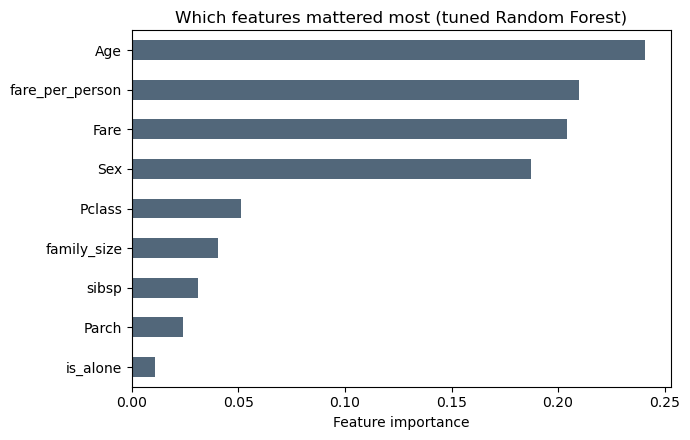

In [10]:
plt.figure(figsize=(7, 4.5))
importances.plot(kind="barh", color="#52677A")
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Which features mattered most (tuned Random Forest)")
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Final Reflection</b> 

Among the engineered features, <code>`fare_per_person`</code> had the highest feature
importance, with an importance of about 0.210. This suggests that the
passenger-level fare carried more useful information than <code>`family_size`</code>
or <code>`is_alone`</code>.

GridSearchCV selected <code>`max_depth=10`</code> and <code>`n_estimators=200`</code>. The tuned
model achieved an F1-score of 0.517 compared with 0.515 for the untuned
baseline, so the improvement was positive but very small.
</div>


<a id="section8"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li>Engineer features <b>after</b> splitting off the test set, and compute any feature statistics from training data only, to avoid leakage.</li>
<li>Always compare a tuned model against its <b>untuned baseline</b> — tuning is only worth it if it measurably helps.</li>
<li>Run GridSearchCV's cross-validation on the training set only; the held-out test set stays sealed until the Day 5 final evaluation.</li>
<li>Start with a small grid, then widen it around the winning region — a huge grid up front wastes compute on combinations far from the optimum.</li>
<li>Fix <code>random_state=42</code> on every split, every model, and every search, for a fully reproducible tuning run.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#D9C08C; background-color:#52677A; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <ul>
<li><b>Feature engineering</b> — creating, transforming, and selecting inputs — often improves results more than switching to a fancier model, because the model can only ever learn from the columns it is given.</li>
<li>Common techniques: <b>creating</b> features, <b>binning</b>, <b>one-hot encoding</b>, <b>datetime extraction</b>, and <b>scaling</b> — each one closes a specific gap between how information naturally exists and what an algorithm can process.</li>
<li>A <b>parameter</b> is learned during training; a <b>hyperparameter</b> is set beforehand and must be searched, not guessed — this distinction is what makes model behaviour explainable rather than magical.</li>
<li><b>GridSearchCV</b> automates that search by cross-validating every combination in a grid and reporting the best one via <code>best_params_</code> and <code>best_score_</code>, turning tuning into a reproducible procedure instead of guesswork.</li>
<li>For large grids, <b>RandomizedSearchCV</b> samples a subset of combinations instead of exhaustively trying every one.</li>
</ul>
</div>
